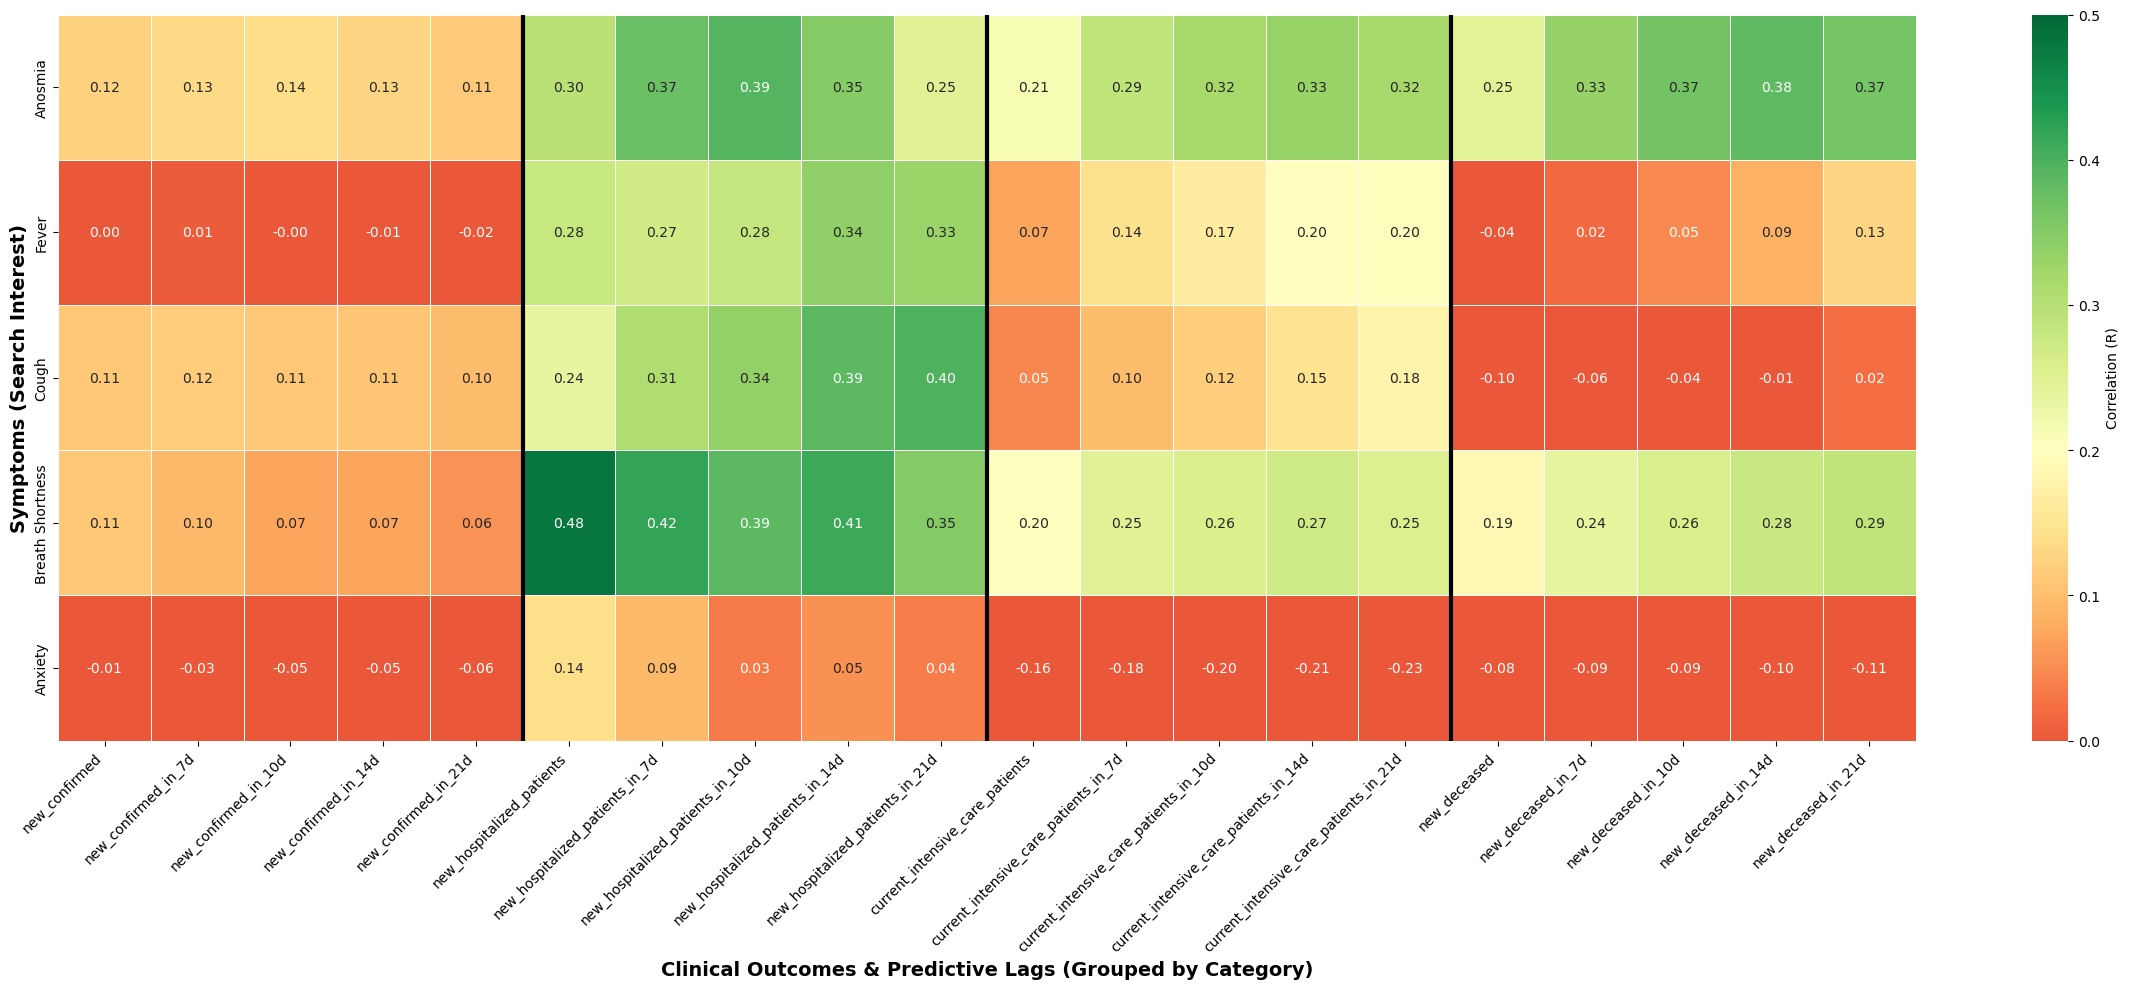

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. טעינה וסידור נתונים
df = pd.read_csv('covid19AndGoogleSearchProject.csv') 
df['report_date'] = pd.to_datetime(df['report_date'])
df = df.sort_values(['country_region', 'report_date'])

symptoms = ['anosmia_score', 'fever_score', 'cough_score', 'breath_shortness_score', 'anxiety_score']
outcomes = ['new_confirmed', 'new_hospitalized_patients', 'current_intensive_care_patients', 'new_deceased']
lags = [7, 10, 14, 21]

df_analysis = df.copy()

# 2. יצירת עמודות מוסטות
for outcome in outcomes:
    for lag in lags:
        df_analysis[f'{outcome}_in_{lag}d'] = df_analysis.groupby('country_region')[outcome].shift(-lag)

# 3. יצירת רשימת עמודות מסודרת לפי תחומים
ordered_columns = []
for o in outcomes:
    ordered_columns.append(o) # המדד המקורי (No Lag)
    for l in lags:
        ordered_columns.append(f'{o}_in_{l}d') # הפיגורים שלו

# 4. חישוב המטריצה
corr_matrix = df_analysis.corr(numeric_only=True).loc[symptoms, ordered_columns]
rename_dict = {s: s.replace('_score', '').replace('_', ' ').title() for s in symptoms}
corr_matrix_clean = corr_matrix.rename(index=rename_dict)

# 5. יצירת ה-Heatmap
plt.figure(figsize=(24, 10))
ax = sns.heatmap(corr_matrix_clean, 
                 annot=True, 
                 cmap='RdYlGn',   
                 center=0.2, 
                 vmin=0, 
                 vmax=0.5, 
                 fmt=".2f", 
                 linewidths=0.5, 
                 linecolor='white',
                 cbar_kws={'label': 'Correlation (R)'})

# הוספת קווי הפרדה אנכיים בין התחומים
for i in range(1, len(outcomes)):
    plt.axvline(i * (len(lags) + 1), color='black', lw=3)

plt.xlabel('Clinical Outcomes & Predictive Lags (Grouped by Category)', fontsize=14, fontweight='bold')
plt.ylabel('Symptoms (Search Interest)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()

plt.savefig('correlation_heatmap_grouped.png', dpi=300, bbox_inches='tight')
plt.show()